In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("quikr_car.csv")
data.sample(5)

,name,company,year,Price,kms_driven,fuel_type
260,Ford Figo Diesel EXI,Ford,2014,"1,95,000","50,000 kms",Diesel
497,Tata Indica,Tata,2005,"80,000","42,000 kms",Petrol
317,Toyota Corolla Altis,Toyota,2009,"1,99,999","65,000 kms",Petrol
22,Maruti Suzuki Alto 800 Vxi,Maruti,2015,"75,000","39,000 kms",Petrol
365,Renault Duster 110PS Diesel RxZ,Renault,2012,"5,01,000","35,000 kms",Diesel


In [3]:
data.shape

(892, 6)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [5]:
data.describe()

,name,company,year,Price,kms_driven,fuel_type
count,892,892,892,892,840,837
unique,525,48,61,274,258,3
top,Honda City,Maruti,2015,Ask For Price,"45,000 kms",Petrol
freq,13,235,117,35,30,440


In [6]:
data["year"].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [7]:
data=data[data["year"].astype(str).str.isnumeric()]

In [8]:
data["year"]=data["year"].astype(int)

In [9]:
data["year"].unique()

array([2007, 2006, 2018, 2014, 2015, 2012, 2013, 2016, 2010, 2017, 2008,
       2011, 2019, 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001])

In [10]:
data=data[data["fuel_type"].notna()]

In [11]:
data=data[data['Price']!='Ask For Price']

In [12]:
data["Price"]=data["Price"].astype(str).str.replace(",","").astype(int)

In [13]:
data["kms_driven"]=data["kms_driven"].astype(str).str.split().str.get(0).str.replace(",","").astype(int)

In [14]:
data["name"]=data["name"].astype(str).str.split().str.slice(start=0,stop=3).str.join(" ")

In [15]:
data=data.reset_index(drop=True)

In [16]:
data.to_csv("final.csv")

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


In [18]:
data.describe(include="all")

,name,company,year,Price,kms_driven,fuel_type
count,816,816,816.000000,8.160000e+02,816.000000,816
unique,254,25,NaN,NaN,NaN,3
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol
freq,51,221,NaN,NaN,NaN,428
mean,NaN,NaN,2012.444853,4.117176e+05,46275.531863,NaN
std,NaN,NaN,4.002992,4.751844e+05,34297.428044,NaN
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,2015.000000,4.912500e+05,56818.500000,NaN


In [19]:
data["company"].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [20]:
data["age"]=2026-data["year"]

In [21]:
data=data[["name",	"company",	'age',	'Price',	'kms_driven',	'fuel_type']]

In [22]:
data

,name,company,age,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,19,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,20,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,12,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,12,575000,36000,Diesel
4,Ford Figo,Ford,14,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,15,270000,50000,Petrol
812,Tata Indica V2,Tata,17,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,17,300000,132000,Petrol
814,Tata Zest XM,Tata,8,260000,27000,Diesel


In [23]:
x=data[["name",	"company",	'age',		'kms_driven',	'fuel_type']]

In [24]:
y=data[["Price"]]

/var/folders/bg/hlmcqqkx54q1c57l8br3tk3h0000gn/T/ipykernel_4945/3241086351.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


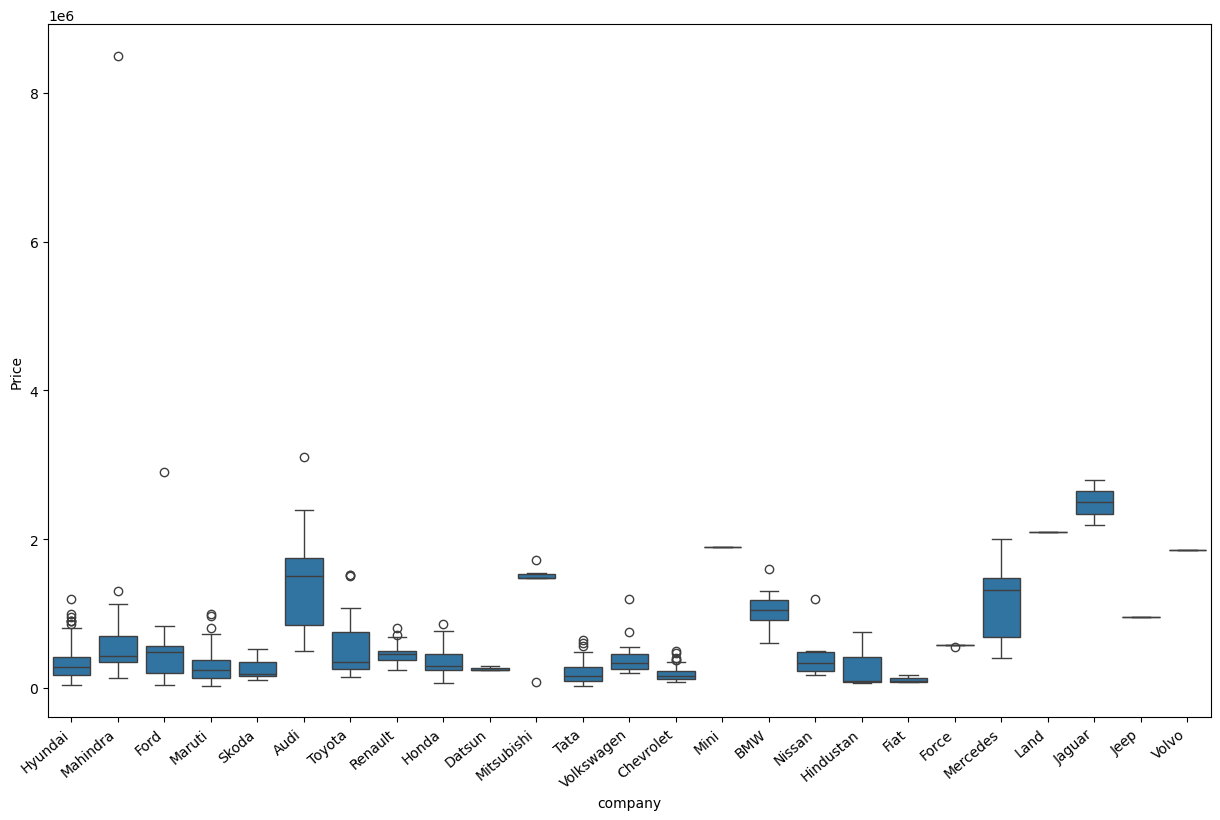

In [25]:
plt.subplots(figsize=(15,9))
ax=sns.boxplot(x="company",y="Price",data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 20.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 39.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 42.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 37.2% of the p

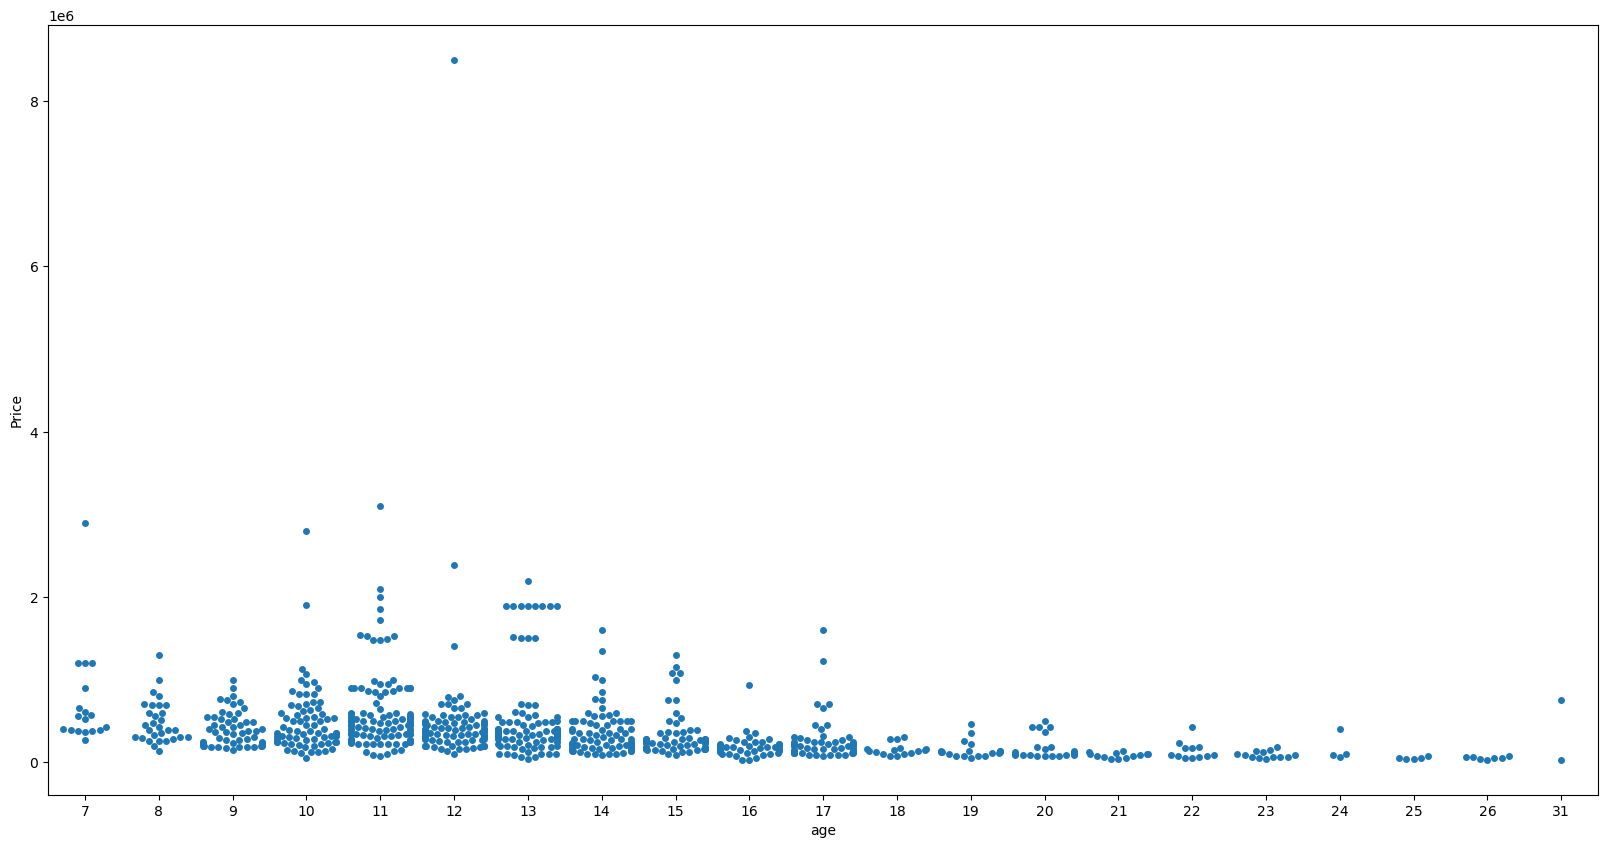

In [27]:
plt.subplots(figsize=(20,10))
sns.swarmplot(x="age",y="Price",data=data)
plt.show()

<Axes: >

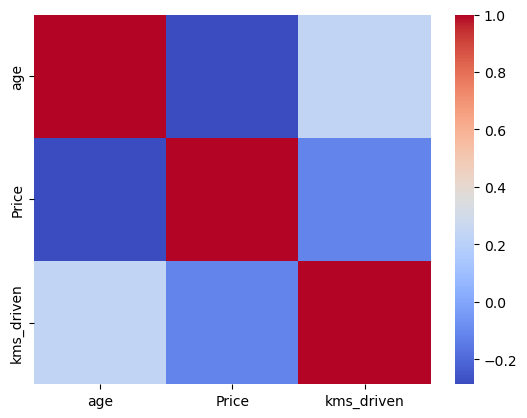

In [28]:
sns.heatmap(data[['age',	'Price',	'kms_driven']].corr(),cmap="coolwarm")

In [29]:
x

,name,company,age,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,19,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,20,40,Diesel
2,Hyundai Grand i10,Hyundai,12,28000,Petrol
3,Ford EcoSport Titanium,Ford,12,36000,Diesel
4,Ford Figo,Ford,14,41000,Diesel
...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,15,50000,Petrol
812,Tata Indica V2,Tata,17,30000,Diesel
813,Toyota Corolla Altis,Toyota,17,132000,Petrol
814,Tata Zest XM,Tata,8,27000,Diesel


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [32]:
column_trans = make_column_transformer(
    (
        OneHotEncoder(handle_unknown='ignore'),
        ['name','company','fuel_type']
    ),
    remainder='passthrough'
)

In [33]:
lr=LinearRegression()

In [34]:
pipe=make_pipeline(
    column_trans,lr
)

In [35]:
pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['name','company','age','kms_driven','fuel_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

In [36]:
y_pred=pipe.predict(x_test)

In [37]:
from sklearn.metrics import r2_score

In [42]:
r2_score(y_test,y_pred)

0.7430847745713096

In [39]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [40]:
np.argmax(scores)

np.int64(247)

In [41]:
scores[np.argmax(scores)]

0.860384309323301

In [43]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',11,100,'Petrol']).reshape(1,5)))

array([[324934.1209348]])

In [44]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',7,10000,'Petrol']).reshape(1,5)))

array([[450388.52228581]])

In [46]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()

In [47]:
pipe2=make_pipeline(
    column_trans,rfr
)

In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [49]:
pipe2.fit(x_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['name','company','age','kms_driven','fuel_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conc

In [50]:
x_train

,name,company,age,kms_driven,fuel_type
39,Honda City 1.5,Honda,15,33000,Petrol
507,Maruti Suzuki Ritz,Maruti,16,72160,Diesel
361,Mahindra Jeep CL550,Mahindra,7,0,Diesel
48,Mahindra Bolero DI,Mahindra,9,23452,Diesel
163,Tata Indigo CS,Tata,15,11400,Diesel
...,...,...,...,...,...
177,Tata Indigo eCS,Tata,10,175430,Diesel
440,Hyundai Elite i20,Hyundai,11,20000,Petrol
209,Force Motors Force,Force,11,3200,Diesel
792,Hyundai Santro Xing,Hyundai,22,137495,Petrol


In [51]:
y_pred2=pipe2.predict(x_test)

In [52]:
r2_score(y_test,y_pred2)

0.8034254629676797

In [45]:
import pickle

pickle.dump(pipe, open("model.pkl", "wb"))

In [46]:

pickle.dump(sorted(data["company"].unique()),open("company.pkl","wb"))

In [47]:
import pickle

pickle.dump(
    data.groupby("company")["name"]
        .unique()
        .apply(list)
        .to_dict(),
    open("name.pkl", "wb")
)

In [48]:
data["fuel_type"].unique()

array(['Petrol', 'Diesel', 'LPG'], dtype=object)

In [49]:
x


,name,company,age,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,19,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,20,40,Diesel
2,Hyundai Grand i10,Hyundai,12,28000,Petrol
3,Ford EcoSport Titanium,Ford,12,36000,Diesel
4,Ford Figo,Ford,14,41000,Diesel
...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,15,50000,Petrol
812,Tata Indica V2,Tata,17,30000,Diesel
813,Toyota Corolla Altis,Toyota,17,132000,Petrol
814,Tata Zest XM,Tata,8,27000,Diesel


In [50]:
print(x.columns)

Index(['name', 'company', 'age', 'kms_driven', 'fuel_type'], dtype='object')
